In [27]:
from __future__ import annotations

import math
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [28]:
DATA_PATH = Path("/mnt/primary/Calibration Data/sp500_100_companies_10years_calibration_data.csv")
LLM_FEATURE_CSV = Path("/mnt/primary/Finnhub Pipeline/llm_financial_features/llm_financial_features.csv")

MODEL_ROOT = Path("/mnt/primary/Baseline/baseline models/saved_models")
MODEL_DIRECTORIES = {
    "Elastic Net": MODEL_ROOT / "ElasticNet",
    "Random Forest": MODEL_ROOT / "RandomForest",
}

HISTORY_START_DATE = pd.Timestamp("2026-01-01")
START_DATE = pd.Timestamp("2026-07-15")
FEATURE_CUTOFF_DATE = pd.Timestamp("2026-08-28")
HORIZONS = [1, 3, 5]

MIN_CALIBRATION_OBSERVATIONS = 200
COEFFICIENT_GRID = np.round(np.arange(-0.0200, 0.0201, 0.00025), 5)

OUTPUT_ROOT = Path("/mnt/primary/Finnhub Pipeline/llm_calibration_results")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Market data:", DATA_PATH.resolve())
print("LLM feature CSV:", LLM_FEATURE_CSV.resolve())
print("Models:", list(MODEL_DIRECTORIES))
print("OHLCV history starts:", HISTORY_START_DATE.date())
print("Feature period:", START_DATE.date(), "to", FEATURE_CUTOFF_DATE.date())
print("Coefficient grid:", COEFFICIENT_GRID.min(), "to", COEFFICIENT_GRID.max(), "| values:", len(COEFFICIENT_GRID))


Market data: /mnt/primary/Calibration Data/sp500_100_companies_10years_calibration_data.csv
LLM feature CSV: /mnt/primary/Finnhub Pipeline/llm_financial_features/llm_financial_features.csv
Models: ['Elastic Net', 'Random Forest']
OHLCV history starts: 2026-01-01
Feature period: 2026-07-15 to 2026-08-28
Coefficient grid: -0.02 to 0.02 | values: 161


In [29]:
REQUIRED_COLUMNS = {"Date", "Symbol", "Open", "High", "Low", "Close", "Volume"}


def load_market_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Market data CSV not found: {path}")

    data = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(data.columns)

    if missing:
        raise ValueError(f"Market data is missing columns: {sorted(missing)}")

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce").dt.normalize()
    data["Symbol"] = data["Symbol"].astype(str).str.strip().str.upper()

    price_column = "Adj Close" if "Adj Close" in data.columns else "Close"
    data["AdjustedPrice"] = pd.to_numeric(data[price_column], errors="coerce")

    for column in ["Open", "High", "Low", "Close", "AdjustedPrice", "Volume"]:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    data = (
        data.dropna(subset=["Date", "Symbol", "AdjustedPrice"])
        .sort_values(["Symbol", "Date"])
        .reset_index(drop=True)
    )

    return data


market_data = load_market_data(DATA_PATH)
market_data = (market_data[market_data["Date"] >= HISTORY_START_DATE].copy().reset_index(drop=True))

print("Rows:", f"{len(market_data):,}")
print("Companies:", market_data["Symbol"].nunique())
print("OHLCV working range:", market_data["Date"].min().date(), "to", market_data["Date"].max().date())
print("Feature dates:", START_DATE.date(), "to", FEATURE_CUTOFF_DATE.date())

if market_data["Date"].max() <= FEATURE_CUTOFF_DATE:
    print()
    print(f"WARNING: OHLCV does not contain dates after {FEATURE_CUTOFF_DATE.date()}.")
    print("Late 1D/3D/5D predictions near the cutoff cannot be evaluated until later OHLCV prices are added.")


Rows: 16,977
Companies: 100
OHLCV working range: 2026-01-02 to 2026-09-04
Feature dates: 2026-07-15 to 2026-08-28


In [30]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.replace(0, np.nan)


def engineer_features_for_company(company: pd.DataFrame) -> pd.DataFrame:
    company = company.sort_values("Date").copy()

    price = company["AdjustedPrice"]
    high = company["High"]
    low = company["Low"]
    open_price = company["Open"]
    volume = company["Volume"]

    for window in [28, 63, 126]:
        company[f"Return_{window}D"] = price.pct_change(window)
        company[f"Volatility_{window}D"] = price.pct_change().rolling(window).std()
        company[f"MeanPrice_{window}D"] = price.rolling(window).mean()
        company[f"Price_to_Mean_{window}D"] = safe_divide(price, company[f"MeanPrice_{window}D"])

    for window in [1, 3, 5, 10, 20]:
        company[f"Return_{window}D"] = price.pct_change(window)

    for lag in [1, 2, 3, 5, 10]:
        company[f"Return_1D_Lag_{lag}"] = company["Return_1D"].shift(lag)

    for window in [5, 10, 20, 50, 100]:
        company[f"Price_to_MA_{window}"] = safe_divide(price, price.rolling(window).mean())

    for window in [5, 10, 20, 50]:
        company[f"Volatility_{window}D"] = price.pct_change().rolling(window).std()

    rolling_high_20 = high.rolling(20).max()
    rolling_low_20 = low.rolling(20).min()

    company["Price_to_20D_High"] = safe_divide(price, rolling_high_20)
    company["Price_to_20D_Low"] = safe_divide(price, rolling_low_20)
    company["Intraday_Return"] = safe_divide(price, open_price) - 1
    company["High_Low_Range"] = safe_divide(high - low, open_price)
    company["Close_Position_In_Range"] = safe_divide(price - low, high - low)
    company["Overnight_Gap"] = safe_divide(open_price, price.shift(1)) - 1
    company["Volume_Change_1D"] = volume.pct_change(1)
    company["Volume_Change_5D"] = volume.pct_change(5)

    for window in [5, 20, 50]:
        company[f"Relative_Volume_{window}"] = safe_divide(volume, volume.rolling(window).mean())

    delta = price.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = safe_divide(gain.rolling(14).mean(), loss.rolling(14).mean())
    company["RSI_14"] = 100 - (100 / (1 + rs))

    ema_12 = price.ewm(span=12, adjust=False).mean()
    ema_26 = price.ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    macd_signal = macd.ewm(span=9, adjust=False).mean()

    company["MACD_Relative"] = safe_divide(macd, price)
    company["MACD_Signal_Relative"] = safe_divide(macd_signal, price)
    company["MACD_Histogram_Relative"] = safe_divide(macd - macd_signal, price)

    ma_20 = price.rolling(20).mean()
    std_20 = price.rolling(20).std()
    upper_band = ma_20 + (2 * std_20)
    lower_band = ma_20 - (2 * std_20)

    company["Bollinger_Width"] = safe_divide(upper_band - lower_band, ma_20)
    company["Bollinger_Position"] = safe_divide(price - lower_band, upper_band - lower_band)

    previous_close = price.shift(1)
    true_range = pd.concat(
        [high - low, (high - previous_close).abs(), (low - previous_close).abs()],
        axis=1,
    ).max(axis=1)

    company["ATR_14_Relative"] = safe_divide(true_range.rolling(14).mean(), price)
    company["Day_Of_Week"] = company["Date"].dt.dayofweek
    company["Month"] = company["Date"].dt.month
    company["Quarter"] = company["Date"].dt.quarter

    for horizon in HORIZONS:
        future_price = price.shift(-horizon)
        company[f"FuturePrice_{horizon}D"] = future_price
        company[f"ActualReturn_{horizon}D"] = safe_divide(future_price, price) - 1
        company[f"TargetDate_{horizon}D"] = company["Date"].shift(-horizon)

    return company


BASIC_FEATURES = [
    "Return_28D", "Return_63D", "Return_126D",
    "Volatility_28D", "Volatility_63D", "Volatility_126D",
    "MeanPrice_28D", "MeanPrice_63D", "MeanPrice_126D",
    "Price_to_Mean_28D", "Price_to_Mean_63D", "Price_to_Mean_126D",
]

ADVANCED_FEATURES = BASIC_FEATURES + [
    "Return_1D", "Return_3D", "Return_5D", "Return_10D", "Return_20D",
    "Return_1D_Lag_1", "Return_1D_Lag_2", "Return_1D_Lag_3", "Return_1D_Lag_5", "Return_1D_Lag_10",
    "Price_to_MA_5", "Price_to_MA_10", "Price_to_MA_20", "Price_to_MA_50", "Price_to_MA_100",
    "Volatility_5D", "Volatility_10D", "Volatility_20D", "Volatility_50D",
    "Price_to_20D_High", "Price_to_20D_Low", "Intraday_Return", "High_Low_Range",
    "Close_Position_In_Range", "Overnight_Gap", "Volume_Change_1D", "Volume_Change_5D",
    "Relative_Volume_5", "Relative_Volume_20", "Relative_Volume_50", "RSI_14",
    "MACD_Relative", "MACD_Signal_Relative", "MACD_Histogram_Relative",
    "Bollinger_Width", "Bollinger_Position", "ATR_14_Relative",
    "Day_Of_Week", "Month", "Quarter",
]

FEATURE_SETS = {"Basic": BASIC_FEATURES, "Advanced": ADVANCED_FEATURES}

featured_frames = []

for symbol in sorted(market_data["Symbol"].unique()):
    company = (market_data[market_data["Symbol"] == symbol].sort_values("Date").copy())
    company = engineer_features_for_company(company)
    company = company[
        (company["Date"] >= START_DATE)
        & (company["Date"] <= FEATURE_CUTOFF_DATE)
    ].copy()

    if not company.empty:
        featured_frames.append(company)

if not featured_frames:
    raise ValueError("No engineered rows were produced in the calibration window.")

featured_data = pd.concat(featured_frames, ignore_index=True)
featured_data = featured_data.replace([np.inf, -np.inf], np.nan)
del featured_frames

print("Basic feature count:", len(BASIC_FEATURES))
print("Advanced feature count:", len(ADVANCED_FEATURES))
print("Engineered calibration rows:", len(featured_data))
print("Companies:", featured_data["Symbol"].nunique())
print("Feature-date range:", featured_data["Date"].min().date(), "to", featured_data["Date"].max().date())

for horizon in HORIZONS:
    print(f"{horizon}D realised targets available:", int(featured_data[f"FuturePrice_{horizon}D"].notna().sum()))


Basic feature count: 12
Advanced feature count: 52
Engineered calibration rows: 3282
Companies: 100
Feature-date range: 2026-07-15 to 2026-08-28
1D realised targets available: 3281
3D realised targets available: 3279
5D realised targets available: 3277


## 5. Load direct LLM-generated financial features

In [31]:
COMMON_COLUMNS = ["Date", "Symbol", "News_Available", "Answer_Available"]
HORIZON_FEATURE_COLUMNS = []

for horizon in HORIZONS:
    HORIZON_FEATURE_COLUMNS.extend(
        [
            f"News_Signal_{horizon}D",
            f"Answer_Quality_Adjusted_Signal_{horizon}D",
        ]
    )

REQUIRED_LLM_COLUMNS = COMMON_COLUMNS + HORIZON_FEATURE_COLUMNS

if not LLM_FEATURE_CSV.exists():
    raise FileNotFoundError(f"University-LLM feature CSV not found: {LLM_FEATURE_CSV.resolve()}")

file_size_mb = LLM_FEATURE_CSV.stat().st_size / (1024 ** 2)
print(f"LLM feature file size: {file_size_mb:.2f} MB")

available_columns = pd.read_csv(LLM_FEATURE_CSV, nrows=0).columns.tolist()
missing = set(REQUIRED_LLM_COLUMNS) - set(available_columns)

if missing:
    raise ValueError(f"LLM feature CSV is missing required columns: {sorted(missing)}")

llm_features = pd.read_csv(LLM_FEATURE_CSV, usecols=REQUIRED_LLM_COLUMNS)
llm_features["Date"] = pd.to_datetime(llm_features["Date"], errors="coerce").dt.normalize()
llm_features["Symbol"] = llm_features["Symbol"].astype("string").str.strip().str.upper()
llm_features = llm_features.dropna(subset=["Date", "Symbol"])
llm_features = llm_features.loc[
    (llm_features["Date"] >= START_DATE)
    & (llm_features["Date"] <= FEATURE_CUTOFF_DATE)
].copy()

for column in HORIZON_FEATURE_COLUMNS:
    llm_features[column] = pd.to_numeric(llm_features[column], errors="coerce").astype("float32").fillna(0.0)

llm_features["News_Available"] = llm_features["News_Available"].fillna(False).astype(bool)
llm_features["Answer_Available"] = llm_features["Answer_Available"].fillna(False).astype(bool)

llm_features = (
    llm_features.drop_duplicates(subset=["Date", "Symbol"], keep="last")
    .sort_values(["Date", "Symbol"])
    .reset_index(drop=True)
)


def signal_columns_for_horizon(horizon: int) -> tuple[str, str]:
    return f"News_Signal_{horizon}D", f"Answer_Quality_Adjusted_Signal_{horizon}D"


print()
print("=" * 70)
print("DIRECT LLM COMPOSITE FEATURES LOADED")
print("=" * 70)
print("Rows:", len(llm_features))
print("Companies:", llm_features["Symbol"].nunique())

if not llm_features.empty:
    print("LLM feature range:", llm_features["Date"].min().date(), "to", llm_features["Date"].max().date())

print("Rows with news:", int(llm_features["News_Available"].sum()))
print("Rows with answers:", int(llm_features["Answer_Available"].sum()))
print("Composite calibration columns by horizon:")

for horizon in HORIZONS:
    news_column, answer_column = signal_columns_for_horizon(horizon)
    print(f"{horizon}D: News = {news_column} | Answer = {answer_column}")

display(llm_features.head(10))


LLM feature file size: 4.02 MB

DIRECT LLM COMPOSITE FEATURES LOADED
Rows: 4390
Companies: 100
LLM feature range: 2026-07-15 to 2026-08-28
Rows with news: 4135
Rows with answers: 4390
Composite calibration columns by horizon:
1D: News = News_Signal_1D | Answer = Answer_Quality_Adjusted_Signal_1D
3D: News = News_Signal_3D | Answer = Answer_Quality_Adjusted_Signal_3D
5D: News = News_Signal_5D | Answer = Answer_Quality_Adjusted_Signal_5D


,Date,Symbol,News_Available,News_Signal_1D,News_Signal_3D,News_Signal_5D,Answer_Available,Answer_Quality_Adjusted_Signal_1D,Answer_Quality_Adjusted_Signal_3D,Answer_Quality_Adjusted_Signal_5D
0,2026-07-15,AAPL,True,-0.1680,-0.1120,0.0000,True,0.0770,0.1155,0.1155
1,2026-07-15,ABNB,True,0.0936,0.1170,0.0936,True,0.0600,0.0900,0.0900
2,2026-07-15,ACN,True,0.0600,0.0450,0.0300,True,0.0510,0.0765,0.1020
3,2026-07-15,ADBE,True,0.0480,0.0720,0.0960,True,0.0000,0.0000,0.0000
4,2026-07-15,AEP,True,0.3060,0.3825,0.3825,True,0.0200,0.0300,0.0300
5,2026-07-15,AES,True,-0.1920,-0.2400,-0.2400,True,0.0240,0.0240,0.0180
6,2026-07-15,AFL,True,0.0360,0.0270,0.0180,True,-0.0180,-0.0300,-0.0240
7,2026-07-15,AIG,True,0.0600,0.0900,0.0900,True,0.0600,0.0900,0.0900
8,2026-07-15,AMZN,True,0.0000,0.0000,0.0000,True,0.0000,0.0000,0.0000
9,2026-07-15,AOS,True,0.0192,0.0135,0.0058,True,-0.0140,-0.0140,-0.0070


In [32]:
prediction_frames = []
missing_model_records = []

for model_name, model_directory in MODEL_DIRECTORIES.items():
    if not model_directory.exists():
        print("Missing model directory:", model_directory)
        continue

    model_files = sorted(model_directory.glob("*.joblib"))
    print(model_name, "| company packages:", len(model_files))

    for model_path in model_files:
        symbol = model_path.stem
        package = joblib.load(model_path)

        company = (featured_data[featured_data["Symbol"] == symbol].sort_values("Date").copy())
        company = company[
            (company["Date"] >= START_DATE)
            & (company["Date"] <= FEATURE_CUTOFF_DATE)
        ].copy()

        company_llm = llm_features[llm_features["Symbol"] == symbol][
            ["Date", "News_Available", "Answer_Available", *HORIZON_FEATURE_COLUMNS]
        ].copy()

        company = company.merge(company_llm, on="Date", how="inner", validate="one_to_one")

        if company.empty:
            continue

        for feature_set_name, feature_columns in FEATURE_SETS.items():
            for horizon in HORIZONS:
                saved_model = package["FeatureSets"].get(feature_set_name, {}).get(horizon)

                if saved_model is None:
                    missing_model_records.append(
                        {
                            "ML_Model": model_name,
                            "Symbol": symbol,
                            "FeatureSet": feature_set_name,
                            "Horizon_Days": horizon,
                        }
                    )
                    continue

                future_price_column = f"FuturePrice_{horizon}D"
                actual_return_column = f"ActualReturn_{horizon}D"
                target_date_column = f"TargetDate_{horizon}D"
                news_signal_column, answer_signal_column = signal_columns_for_horizon(horizon)

                required_columns = [
                    *feature_columns,
                    "AdjustedPrice",
                    future_price_column,
                    actual_return_column,
                    target_date_column,
                    news_signal_column,
                    answer_signal_column,
                ]

                usable = company.dropna(subset=required_columns).copy()

                if usable.empty:
                    continue

                predicted_return = saved_model.predict(usable[feature_columns])
                current_price = usable["AdjustedPrice"].to_numpy()
                baseline_price = current_price * (1 + predicted_return)

                frame = pd.DataFrame(
                    {
                        "ML_Model": model_name,
                        "FeatureSet": feature_set_name,
                        "Horizon_Days": horizon,
                        "FeatureDate": usable["Date"].to_numpy(),
                        "TargetDate": usable[target_date_column].to_numpy(),
                        "Symbol": symbol,
                        "CurrentPrice": current_price,
                        "ActualFuturePrice": usable[future_price_column].to_numpy(),
                        "ActualReturn": usable[actual_return_column].to_numpy(),
                        "BaselinePredictedReturn": predicted_return,
                        "BaselinePredictedPrice": baseline_price,
                        "News_Calibration_Signal": usable[news_signal_column].to_numpy(),
                        "Answer_Calibration_Signal": usable[answer_signal_column].to_numpy(),
                        "News_Signal_Column": news_signal_column,
                        "Answer_Signal_Column": answer_signal_column,
                        "News_Available": usable["News_Available"].to_numpy(),
                        "Answer_Available": usable["Answer_Available"].to_numpy(),
                    }
                )

                prediction_frames.append(frame)

predictions = pd.concat(prediction_frames, ignore_index=True)
predictions["FeatureDate"] = pd.to_datetime(predictions["FeatureDate"]).dt.normalize()
predictions["TargetDate"] = pd.to_datetime(predictions["TargetDate"]).dt.normalize()

print("Prediction rows:", len(predictions))
print("Companies:", predictions["Symbol"].nunique())
print("Feature range:", predictions["FeatureDate"].min().date(), "to", predictions["FeatureDate"].max().date())
print("Latest target date:", predictions["TargetDate"].max().date())


Elastic Net | company packages: 99
Random Forest | company packages: 99
Prediction rows: 37692
Companies: 99
Feature range: 2026-07-15 to 2026-08-28
Latest target date: 2026-09-04


In [33]:
assert predictions["FeatureDate"].max() <= FEATURE_CUTOFF_DATE
assert llm_features["Date"].max() <= FEATURE_CUTOFF_DATE

print("✓ All predictive feature dates are on or before", FEATURE_CUTOFF_DATE.date())
print("✓ OHLCV after the cutoff is used only for realised target prices.")


✓ All predictive feature dates are on or before 2026-08-28
✓ OHLCV after the cutoff is used only for realised target prices.


In [34]:
def rmse(actual, predicted) -> float:
    return math.sqrt(mean_squared_error(actual, predicted))


def _price_adjustment_arrays(history: pd.DataFrame):
    y = history["ActualFuturePrice"].to_numpy() - history["BaselinePredictedPrice"].to_numpy()
    current_price = history["CurrentPrice"].to_numpy()
    news_x = current_price * history["News_Calibration_Signal"].to_numpy()
    answer_x = current_price * history["Answer_Calibration_Signal"].to_numpy()
    return y, news_x, answer_x


def find_best_news_alpha(history: pd.DataFrame) -> tuple[float, float]:
    if len(history) < MIN_CALIBRATION_OBSERVATIONS:
        return 0.0, np.nan

    y, news_x, _ = _price_adjustment_arrays(history)
    y2 = np.dot(y, y)
    yx = np.dot(y, news_x)
    xx = np.dot(news_x, news_x)

    grid = COEFFICIENT_GRID
    sse = y2 - (2.0 * grid * yx) + ((grid ** 2) * xx)

    best_index = int(np.argmin(sse))
    best_alpha = float(grid[best_index])
    best_rmse = math.sqrt(max(float(sse[best_index]), 0.0) / len(history))

    return best_alpha, best_rmse


def find_best_answer_beta_after_news(history: pd.DataFrame, news_alpha: float) -> tuple[float, float]:
    if len(history) < MIN_CALIBRATION_OBSERVATIONS:
        return 0.0, np.nan

    y, news_x, answer_x = _price_adjustment_arrays(history)
    residual_after_news = y - (news_alpha * news_x)

    y2 = np.dot(residual_after_news, residual_after_news)
    yx = np.dot(residual_after_news, answer_x)
    xx = np.dot(answer_x, answer_x)

    grid = COEFFICIENT_GRID
    sse = y2 - (2.0 * grid * yx) + ((grid ** 2) * xx)

    best_index = int(np.argmin(sse))
    best_beta = float(grid[best_index])
    best_rmse = math.sqrt(max(float(sse[best_index]), 0.0) / len(history))

    return best_beta, best_rmse


In [35]:
walk_forward_frames = []
group_columns = ["ML_Model", "FeatureSet", "Horizon_Days"]

for group_key, group in predictions.groupby(group_columns):
    model_name, feature_set, horizon = group_key
    group = group.sort_values(["FeatureDate", "Symbol"]).reset_index(drop=True)
    feature_dates = sorted(group["FeatureDate"].unique())

    for feature_date in feature_dates:
        feature_date = pd.Timestamp(feature_date)

        history = group[
            (group["FeatureDate"] < feature_date)
            & (group["TargetDate"] <= feature_date)
        ].copy()

        news_alpha, news_history_rmse = find_best_news_alpha(history)
        answer_beta, news_answer_history_rmse = find_best_answer_beta_after_news(history, news_alpha)

        current = group[group["FeatureDate"] == feature_date].copy()

        current["CalibrationHistoryRows"] = len(history)
        current["News_Alpha"] = news_alpha
        current["Answer_Beta_After_News"] = answer_beta
        current["News_History_RMSE"] = news_history_rmse
        current["News_Answers_History_RMSE"] = news_answer_history_rmse

        current["NewsCalibratedReturn"] = (
            current["BaselinePredictedReturn"] + (news_alpha * current["News_Calibration_Signal"])
        )
        current["NewsCalibratedPrice"] = current["CurrentPrice"] * (1 + current["NewsCalibratedReturn"])

        current["NewsAnswersCalibratedReturn"] = (
            current["NewsCalibratedReturn"] + (answer_beta * current["Answer_Calibration_Signal"])
        )
        current["NewsAnswersCalibratedPrice"] = (
            current["CurrentPrice"] * (1 + current["NewsAnswersCalibratedReturn"])
        )

        walk_forward_frames.append(current)

walk_forward = (
    pd.concat(walk_forward_frames, ignore_index=True)
    .sort_values(["FeatureDate", "ML_Model", "FeatureSet", "Horizon_Days", "Symbol"])
    .reset_index(drop=True)
)

print("Walk-forward rows:", len(walk_forward))
print(
    "Rows after calibration warm-up:",
    int((walk_forward["CalibrationHistoryRows"] >= MIN_CALIBRATION_OBSERVATIONS).sum()),
)
print("Walk-forward calibration complete.")


Walk-forward rows: 37692
Rows after calibration warm-up: 31752
Walk-forward calibration complete.


In [36]:
def calculate_company_rmse(group: pd.DataFrame) -> pd.Series:
    actual = group["ActualFuturePrice"].to_numpy()

    prediction_columns = {
        "Baseline": "BaselinePredictedPrice",
        "News": "NewsCalibratedPrice",
        "News_Answers": "NewsAnswersCalibratedPrice",
    }

    metrics = {}

    for variant, column in prediction_columns.items():
        predicted = group[column].to_numpy()
        metrics[f"{variant}_RMSE"] = rmse(actual, predicted)

    return pd.Series(metrics)


company_results = (
    walk_forward.groupby(["ML_Model", "FeatureSet", "Horizon_Days", "Symbol"])
    .apply(calculate_company_rmse)
    .reset_index()
)


In [37]:
overall_results = (
    company_results.groupby(["ML_Model", "FeatureSet", "Horizon_Days"], as_index=False)[
        ["Baseline_RMSE", "News_RMSE", "News_Answers_RMSE"]
    ]
    .mean()
    .sort_values(["Horizon_Days", "ML_Model", "FeatureSet"])
    .reset_index(drop=True)
)

final_results = overall_results.rename(
    columns={
        "Baseline_RMSE": "Baseline RMSE",
        "News_RMSE": "Baseline + News RMSE",
        "News_Answers_RMSE": "Baseline + News + Answers RMSE",
    }
).copy()

final_results.columns.name = None
display(final_results.round(4))


,ML_Model,FeatureSet,Horizon_Days,Baseline RMSE,Baseline + News RMSE,Baseline + News + Answers RMSE
0,Elastic Net,Advanced,1,5.6583,5.7089,5.7199
1,Elastic Net,Basic,1,4.3126,4.3786,4.3868
2,Random Forest,Advanced,1,4.3682,4.4527,4.4610
3,Random Forest,Basic,1,4.5026,4.5925,4.6002
4,Elastic Net,Advanced,3,33.8837,33.8845,33.8714
5,Elastic Net,Basic,3,8.6438,8.7023,8.6957
6,Random Forest,Advanced,3,8.0014,8.0841,8.0914
7,Random Forest,Basic,3,8.2091,8.2944,8.2984
8,Elastic Net,Advanced,5,64.0046,64.0102,64.0066
9,Elastic Net,Basic,5,11.9134,11.9552,11.9535


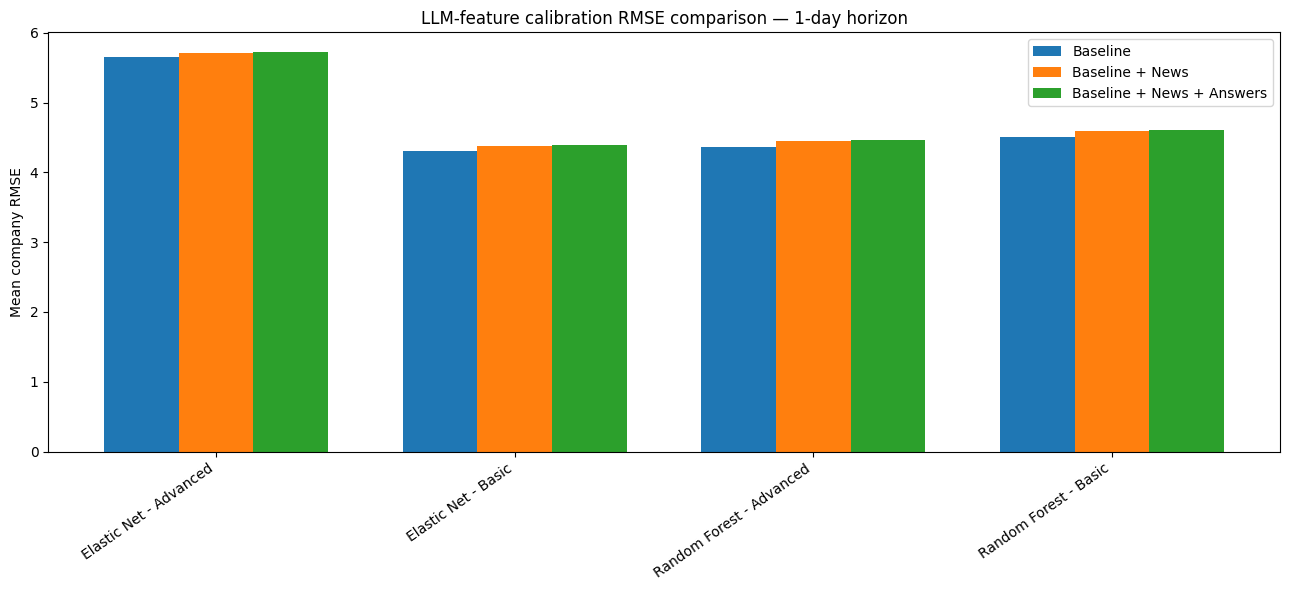

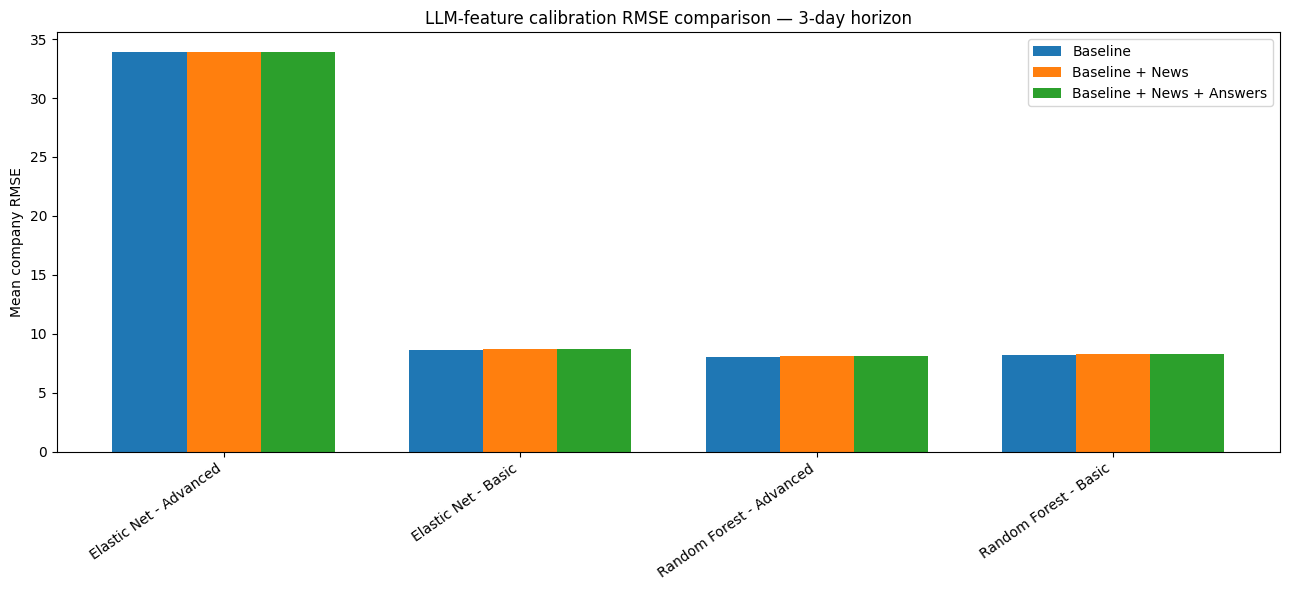

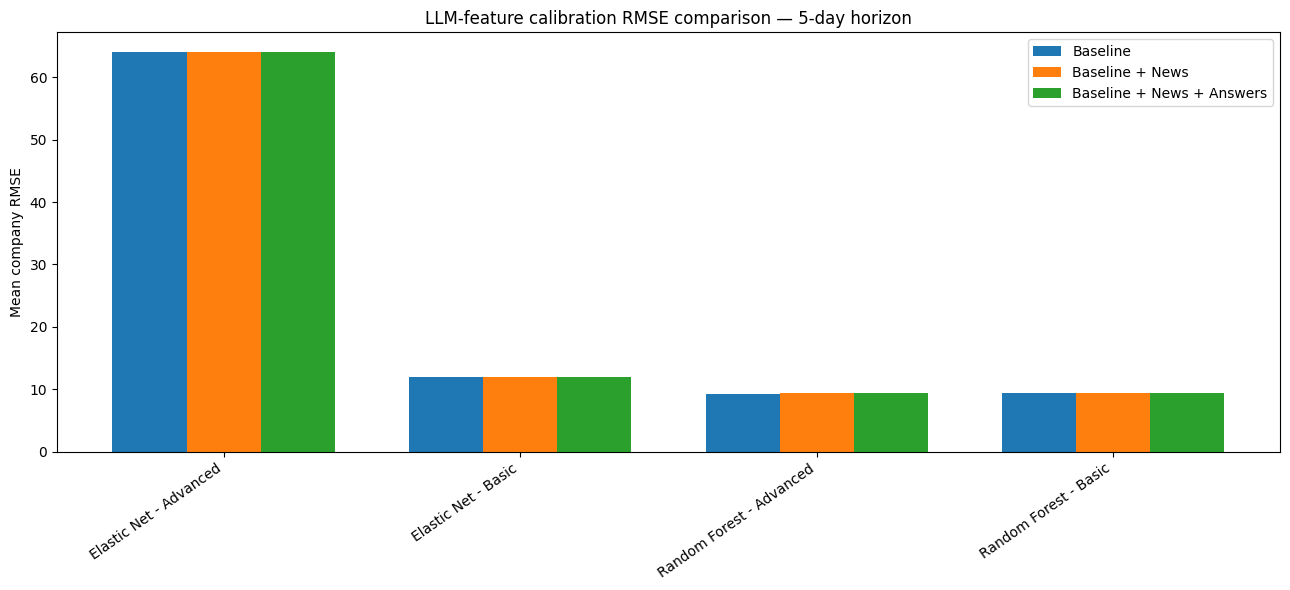

In [38]:
for horizon in HORIZONS:
    subset = overall_results[overall_results["Horizon_Days"] == horizon].copy()

    labels = subset["ML_Model"] + " - " + subset["FeatureSet"]
    positions = np.arange(len(subset))
    width = 0.25

    figure, axis = plt.subplots(figsize=(13, 6))

    axis.bar(positions - width, subset["Baseline_RMSE"], width=width, label="Baseline")
    axis.bar(positions, subset["News_RMSE"], width=width, label="Baseline + News")
    axis.bar(
        positions + width,
        subset["News_Answers_RMSE"],
        width=width,
        label="Baseline + News + Answers",
    )

    axis.set_xticks(positions)
    axis.set_xticklabels(labels, rotation=35, ha="right")
    axis.set_ylabel("Mean company RMSE")
    axis.set_title(f"LLM-feature calibration RMSE comparison — {horizon}-day horizon")
    axis.legend()

    plt.tight_layout()
    plt.show()


In [39]:
company_results.to_csv(OUTPUT_ROOT / "company_level_rmse.csv", index=False)
overall_results.to_csv(OUTPUT_ROOT / "overall_rmse_results.csv", index=False)
final_results.to_csv(OUTPUT_ROOT / "final_rmse_comparison.csv", index=False)

print("Saved RMSE results to:", OUTPUT_ROOT.resolve())


Saved RMSE results to: /mnt/primary/Finnhub Pipeline/llm_calibration_results
